In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)


In [157]:
df = pd.read_csv("../data/processed/penn_state_processed_stats_2024_2025.csv")
df.head(10)

,Date,Opponent,Location,Result,Box Score Link,WMT Game ID,PSU Goals,PSU Shots on Goal,PSU Total Shot Attempts,PSU Faceoffs Won,...,Total Shots on Goal,Faceoff Differential,PSU Save %,Opponent Save %,Home Game,Venue_Type,Total Goals,Total Penalty Minutes,PSU Shooting %,Opponent Shooting %
0,Saturday Oct 5,Alaska,"Fairbanks, Alaska",W Win 4-3,https://gopsusports.com/boxscore/16818,5722151,4,33,65,30,...,62,5.26,0.897,0.879,0,Away,7,14,12.121212,10.344828
1,Sunday Oct 6,Alaska,"Fairbanks, Alaska",W Win 5-0,https://gopsusports.com/boxscore/16819,5722152,5,32,54,35,...,64,-1.40,1.000,0.844,0,Away,5,52,15.625000,0.000000
2,Saturday Oct 12,Quinnipiac,"Hamden, Conn.",L Loss 2-3,https://gopsusports.com/boxscore/16820,5722153,2,20,45,25,...,42,-1.96,0.864,0.900,0,Away,5,14,10.000000,13.636364
3,Friday Oct 25,St. Lawrence,"University Park, Pa. / Pegula Ice Arena",W Win 3-2,https://gopsusports.com/boxscore/16821,5722154,3,28,58,40,...,44,29.04,0.875,0.893,1,Home,5,29,10.714286,12.500000
4,Saturday Oct 26,St. Lawrence,"University Park, Pa. / Pegula Ice Arena",W Win 3-1,https://gopsusports.com/boxscore/16822,5722155,3,37,65,40,...,63,40.36,0.962,0.919,1,Home,4,16,8.108108,3.846154
5,Friday Nov 1,Minnesota,"Minneapolis, Minn.",L Loss 1-3,https://gopsusports.com/boxscore/16933,5722156,1,22,45,27,...,56,0.00,0.912,0.955,0,Away,4,19,4.545455,8.823529
6,Saturday Nov 2,Minnesota,"Minneapolis, Minn.",L Loss 0-1,https://gopsusports.com/boxscore/16934,5722157,0,28,52,28,...,40,0.00,0.917,1.000,0,Away,1,25,0.000000,8.333333
7,Friday Nov 15,Wisconsin,"University Park, Pa. / Pegula Ice Arena",L Loss 4-5,https://gopsusports.com/boxscore/16935,5722160,4,36,62,39,...,64,13.04,0.821,0.889,1,Home,9,16,11.111111,17.857143
8,Saturday Nov 16,Wisconsin,"University Park, Pa. / Pegula Ice Arena",L Loss 3-6,https://gopsusports.com/boxscore/16936,5722161,3,33,59,38,...,64,20.64,0.806,0.909,1,Home,9,17,9.090909,19.354839
9,Friday Nov 22,Michigan,"University Park, Pa. / Pegula Ice Arena",L Loss 5-6,https://gopsusports.com/boxscore/16937,5722162,5,29,56,43,...,54,24.64,0.760,0.828,1,Home,11,12,17.241379,24.000000


In [158]:
features = [
    "PSU Shots on Goal", 
    "Opponent Shots on Goal", 
    "Shot Differential",
    "PSU Faceoff %",
    "Opponent Faceoff %",
    "Faceoff Differential",
    "PSU Shooting %",
    "Opponent Shooting %",
    "Opponent Save %",
    "PSU Blocks",
    "Opponent Blocks",
    "PSU Penalty Minutes",
    "Opponent Penalty Minutes"
]



In [159]:
X = df[features]
y = df["Win"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Training games:", len(X_train))
print("Testing games:", len(X_test))

Training games: 32
Testing games: 8


In [160]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [161]:
predictions = model.predict(X_test)

In [162]:
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.3f}")
print(confusion_matrix(
    y_test,
    predictions
))
print(classification_report(
    y_test,
    predictions
))

Accuracy: 1.000
[[4 0]
 [0 4]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [163]:
feature_importance = pd.DataFrame({"Feature":X.columns, "Coefficient":model.coef_[0]})
feature_importance["Absolute Coefficient"] = (feature_importance["Coefficient"].abs())
feature_importance = feature_importance.sort_values(by = "Absolute Coefficient", ascending = False)
feature_importance

,Feature,Coefficient,Absolute Coefficient
6,PSU Shooting %,1.049649,1.049649
7,Opponent Shooting %,-0.988201,0.988201
11,PSU Penalty Minutes,0.341913,0.341913
2,Shot Differential,0.261845,0.261845
1,Opponent Shots on Goal,-0.187155,0.187155
9,PSU Blocks,0.151701,0.151701
10,Opponent Blocks,0.125022,0.125022
0,PSU Shots on Goal,0.074690,0.074690
3,PSU Faceoff %,-0.051405,0.051405
5,Faceoff Differential,-0.037413,0.037413


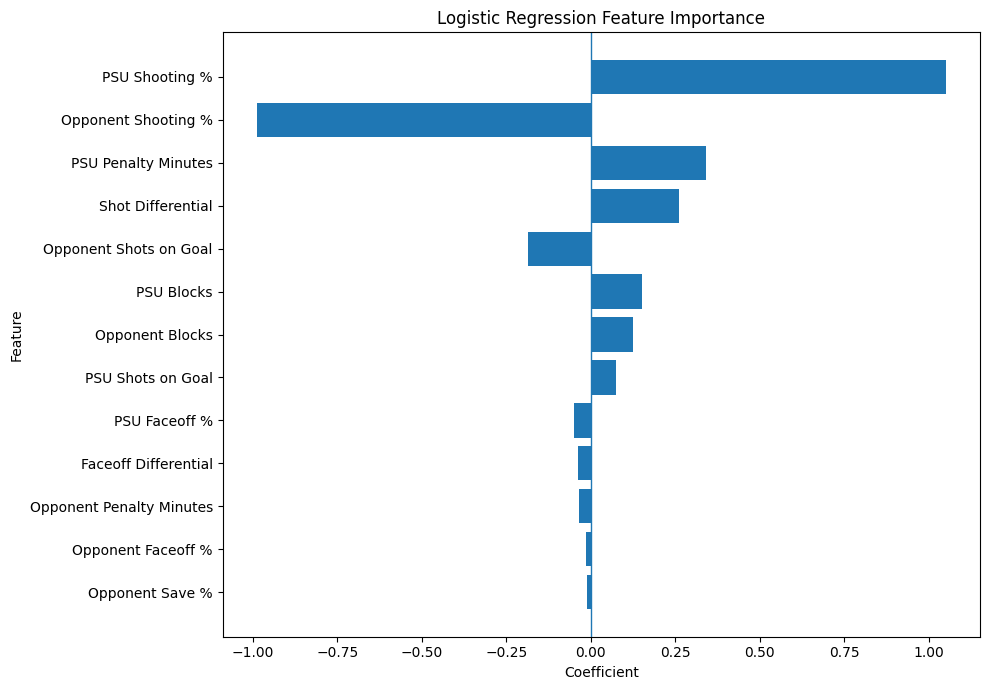

In [164]:

plt.figure(figsize=(10,7))

plt.barh(feature_importance["Feature"],feature_importance["Coefficient"])
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.axvline(0, linewidth=1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

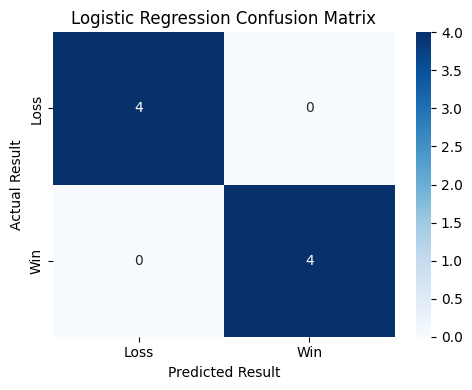

In [165]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")

plt.tight_layout()
plt.show()

In [166]:
models = {
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Decision Tree":DecisionTreeClassifier(random_state=42, max_depth=4),
    "Random Forest":RandomForestClassifier(n_estimators=200, random_state=42, max_depth=5),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42)
}

model_results = []
trained_models = {}

for model_name, current_model in models.items():

    current_model.fit(X_train, y_train)

    current_predictions = current_model.predict(X_test)
    
    current_accuracy = accuracy_score(y_test, current_predictions)

    current_report = classification_report(y_test, current_predictions, output_dict=True, zero_division=0)

    model_results.append({
        "Model" : model_name,
        "Accuracy" : current_accuracy,
        "Precision" : current_report["weighted avg"]["precision"],
        "Recall": current_report["weighted avg"]["recall"],
        "F1 Score": current_report["weighted avg"]["f1-score"]
    })

    trained_models[model_name] = current_model 

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(by=["Accuracy", "F1 Score", "Precision", "Recall"], ascending=False)
print(results_df)


                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression      1.00   1.000000    1.00  1.000000
2        Random Forest      1.00   1.000000    1.00  1.000000
3    Gradient Boosting      1.00   1.000000    1.00  1.000000
1        Decision Tree      0.75   0.833333    0.75  0.733333


                 Model  Mean Accuracy  Std Deviation
0  Logistic Regression          0.850       0.183712
1        Decision Tree          0.750       0.079057
3    Gradient Boosting          0.750       0.111803
2        Random Forest          0.725       0.145774


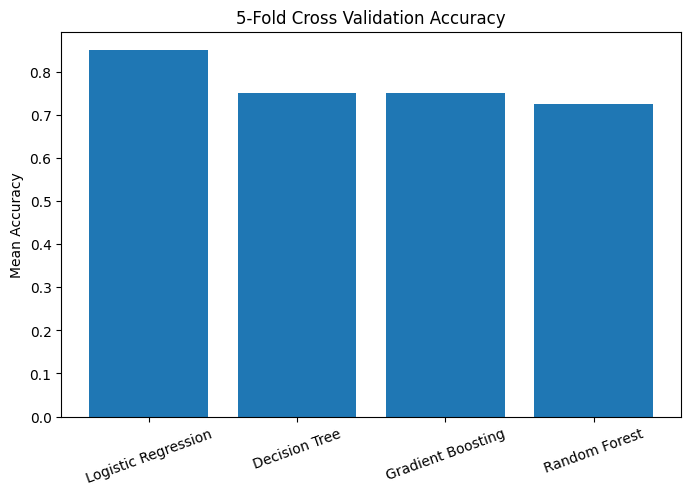

In [167]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, current_model in models.items():

    scores = cross_val_score(
        current_model, X, y, cv=skf, scoring="accuracy"
    )

    cv_results.append({
        "Model":model_name,
        "Mean Accuracy":scores.mean(), 
        "Std Deviation":scores.std()
    })

cv_results = pd.DataFrame(cv_results)
cv_results = cv_results.sort_values(by="Mean Accuracy", ascending=False) 
print(cv_results)
cv_results.to_csv(
    "../reports/cross_validation_results.csv",
    index=False
)

plt.figure(figsize=(8,5))

plt.bar(
    cv_results["Model"],
    cv_results["Mean Accuracy"]
)

plt.ylabel("Mean Accuracy")
plt.title("5-Fold Cross Validation Accuracy")

plt.xticks(rotation=20)

plt.show()

In [168]:
importance_model = trained_models["Random Forest"].feature_importances_
model_feature_importance = pd.DataFrame({
    "Feature": X.columns, 
    "Importance":importance_model
})
model_feature_importance = model_feature_importance.sort_values(by="Importance", ascending=False)
model_feature_importance = model_feature_importance.reset_index(drop=True)
model_feature_importance

model_feature_importance.to_csv(
    "../reports/model_feature_importance.csv",
    index=False
)

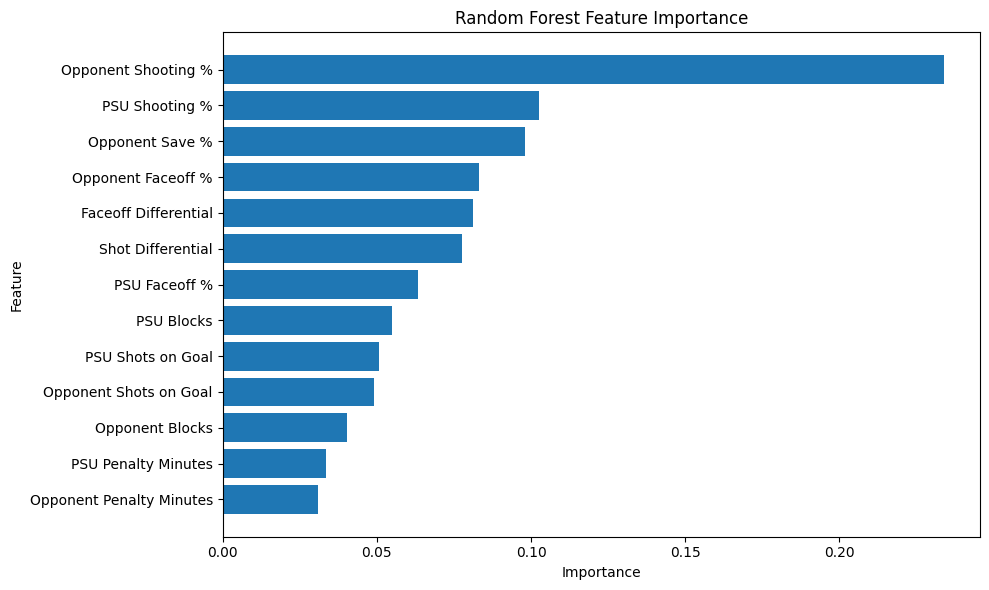

In [169]:
plt.figure(figsize=(10, 6))
plt.barh(
    model_feature_importance["Feature"],
    model_feature_importance["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [170]:
results_df = pd.DataFrame(model_results)
results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.00,1.000000,1.00,1.000000
1,Decision Tree,0.75,0.833333,0.75,0.733333
2,Random Forest,1.00,1.000000,1.00,1.000000
3,Gradient Boosting,1.00,1.000000,1.00,1.000000


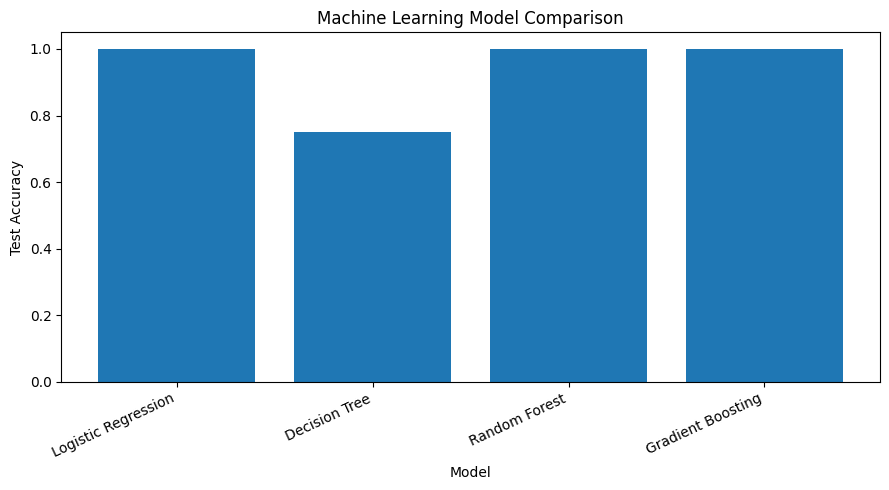

In [171]:
plt.figure(figsize=(9,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.05)

plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

In [172]:
best_model_name = results_df.loc[0, "Model"]

best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print(
    "Best F1 score:",
    round(results_df.loc[0, "F1 Score"], 3)
)

Best model: Logistic Regression
Best F1 score: 1.0


In [173]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/best_hockey_model.joblib"
)

joblib.dump(
    features,
    "../models/model_features.joblib"
)

print("Model and feature list saved successfully.")

Model and feature list saved successfully.
